In [1]:
!pip install luwiji

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from luwiji.cluster import demo

# **Sample Data**

In [3]:
X1, y1 = demo.blob_data()
X2, y2 = demo.moon_data()
X3, y3 = demo.circle_data()

# **Visualize**

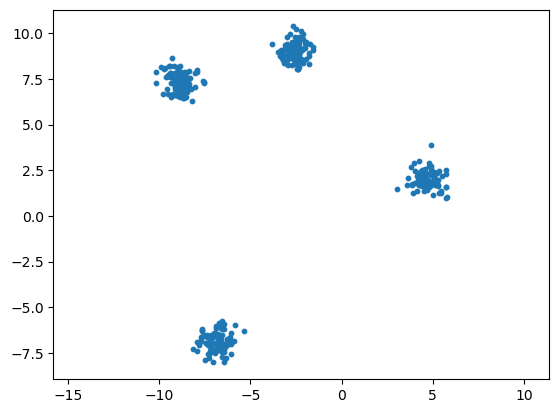

In [4]:
X = X1  #X1 blob data
        #X1 moon data
        #X3 circle data
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.axis("equal");

# **K-Means Clustering**

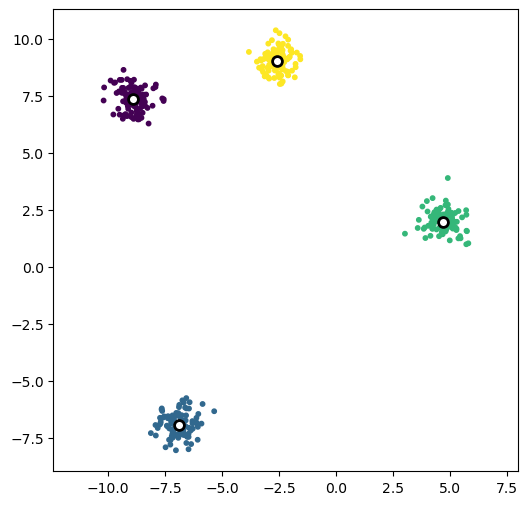

In [5]:
X = X1 #change to X2 for data demo X2 and so on
kmeans = KMeans(n_clusters=4) #X1 has 4 clusters, obviously
#kmeans.fit(X) #we fit only X without y, because unsupervised (clustering) has no label
member = kmeans.fit_predict(X) #save time, directly fit and predict clusters
centre = kmeans.cluster_centers_

plt.figure(figsize=(6, 6))
#plt.scatter(X[:, 0], X[:, 1], s=10)
plt.scatter(X[:, 0], X[:, 1], c=member, s=10) #this with color
plt.scatter(centre[:, 0], centre[:, 1], c="w", edgecolors="k", s=50, linewidths=2)
plt.axis("equal");

In [6]:
member

array([0, 3, 0, 2, 2, 3, 3, 0, 3, 2, 0, 2, 0, 2, 1, 1, 1, 3, 2, 1, 2, 0,
       3, 2, 3, 0, 1, 3, 1, 0, 0, 2, 0, 0, 3, 1, 2, 2, 3, 1, 3, 0, 0, 1,
       2, 2, 3, 1, 3, 2, 3, 0, 1, 2, 2, 0, 2, 3, 0, 2, 1, 2, 0, 1, 3, 3,
       1, 1, 1, 0, 3, 1, 0, 2, 0, 3, 0, 1, 3, 3, 1, 3, 0, 0, 1, 2, 0, 1,
       3, 1, 2, 3, 0, 1, 2, 0, 0, 1, 1, 3, 1, 2, 3, 1, 1, 1, 2, 1, 2, 3,
       3, 0, 2, 2, 0, 0, 0, 2, 0, 3, 1, 2, 0, 3, 0, 1, 1, 2, 1, 3, 3, 3,
       1, 0, 1, 0, 3, 1, 3, 1, 3, 1, 1, 2, 3, 0, 1, 3, 0, 2, 0, 3, 1, 2,
       1, 3, 2, 3, 2, 3, 2, 3, 2, 0, 2, 0, 1, 0, 0, 0, 0, 3, 1, 1, 1, 2,
       2, 3, 2, 0, 1, 2, 2, 2, 1, 2, 3, 3, 1, 1, 2, 0, 0, 2, 1, 1, 0, 1,
       0, 0, 2, 3, 1, 3, 3, 2, 0, 3, 0, 1, 3, 2, 2, 3, 2, 1, 1, 2, 3, 2,
       1, 3, 3, 2, 1, 3, 1, 3, 1, 3, 1, 3, 2, 0, 0, 1, 0, 0, 2, 1, 3, 3,
       0, 3, 1, 1, 2, 3, 2, 2, 2, 2, 3, 1, 2, 1, 3, 2, 0, 0, 3, 2, 2, 0,
       0, 1, 1, 1, 3, 2, 2, 1, 1, 2, 3, 1, 3, 3, 2, 0, 3, 2, 1, 0, 3, 3,
       0, 0, 0, 2, 2, 0, 2, 2, 1, 0, 3, 3, 2, 0, 0,

In [7]:
kmeans.cluster_centers_


array([[-8.8837694 ,  7.3527418 ],
       [-6.88174949, -6.93204687],
       [ 4.69349111,  1.99188198],
       [-2.57121515,  9.02892796]])

# **Weaknesses of K-Means:**


1. Difficult to determine the value of K
* Solution: Use the Elbow Method, Silhouette Score, and other techniques.
2. Only applicable to data that can be averaged
* Solution: Use K-Medoids instead.
3. The solution is not always optimal
* Works only for linearly separable data

# **Example: Moon Dataset**

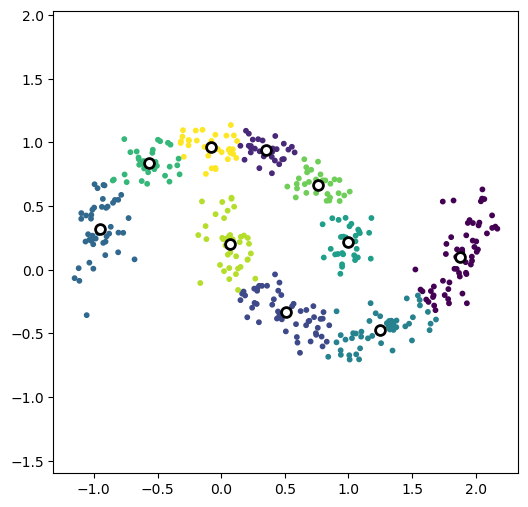

In [8]:
X = X2
kmeans = KMeans(n_clusters=10) # check k=2 or k=3 or k=3 and see the result.
                              # do the same to X3
member = kmeans.fit_predict(X)
centre = kmeans.cluster_centers_

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=member, s=10) #this with color
plt.scatter(centre[:, 0], centre[:, 1], c="w", edgecolors="k", s=50, linewidths=2)
plt.axis("equal");

# **Determining K (number of clusters) using Elbow Analysis**


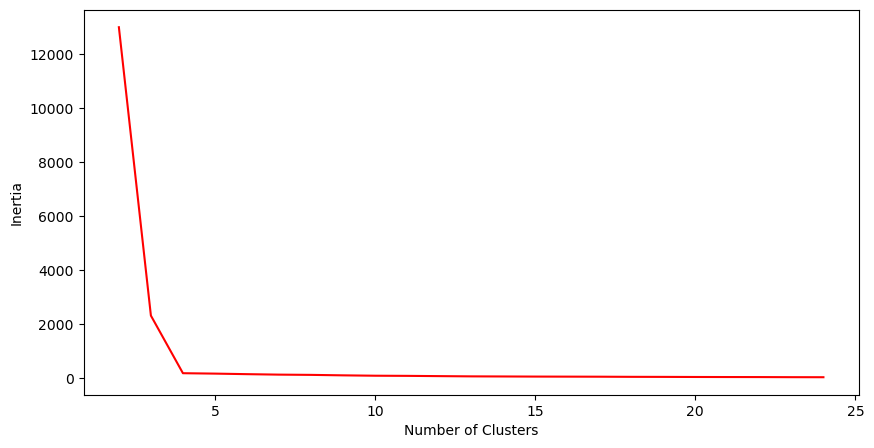

In [9]:
X = X1
score = []
for k in range(2, 25):
    kmeans = KMeans(n_clusters=k)
    member = kmeans.fit_predict(X)
    score.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot( range(2, 25), score, "r-")
plt.ylabel("Inertia")
# the goal of the K-Means algorithm is to minimize inertia.
# inertia is calculated as the sum of the squared distances from each data point
# to its assigned cluster's centroid (center point).
# it is also very commonly called the Within-Cluster Sum of Squares (WCSS)
plt.xlabel("Number of Clusters");


# **Determining K (number of clusters) using the Silhouette Score (requires labeled data)**

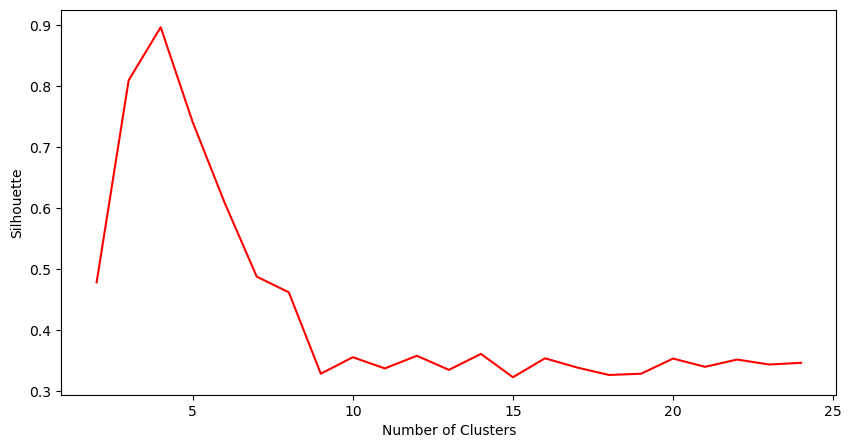

In [10]:
X = X1
score = []
for k in range(2, 25):
    kmeans = KMeans(n_clusters=k)
    member = kmeans.fit_predict(X)
    silhouette = silhouette_score(X, member, metric='euclidean')
    score.append(silhouette)

plt.figure(figsize=(10, 5))
plt.plot( range(2, 25), score, "r-")
plt.ylabel("Silhouette")
plt.xlabel("Number of Clusters");